Hay que meter tiempos

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)

Vamos a sacar algunas gráficas para comprobar la temporalidad de los datos, ya que hay datos recogidos de 3 años, vamos a dividir la columna dispatch_date en años, meses y días (sólo lo haremos con esta ya que anteriormente habíamos comprobado que la columna load_date es igual) - Archivo df_loads_trips.csv


In [2]:
df = pd.read_csv("../datos_transformados/df_loads_trips.csv", sep = ',')
df.shape

(85410, 21)

In [3]:
df.columns

Index(['Unnamed: 0', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'booking_type', 'driver_id', 'truck_id',
       'trailer_id', 'dispatch_date', 'actual_distance_miles',
       'actual_duration_hours', 'fuel_gallons_used', 'average_mpg',
       'idle_time_hours', 'total_revenue'],
      dtype='object')

In [4]:
# df['dispatch_date'] = pd.to_datetime(df['dispatch_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             85410 non-null  int64  
 1   customer_id            85410 non-null  object 
 2   route_id               85410 non-null  object 
 3   load_date              85410 non-null  object 
 4   load_type              85410 non-null  object 
 5   weight_lbs             85410 non-null  int64  
 6   pieces                 85410 non-null  int64  
 7   revenue                85410 non-null  float64
 8   fuel_surcharge         85410 non-null  float64
 9   accessorial_charges    85410 non-null  int64  
 10  booking_type           85410 non-null  object 
 11  driver_id              83696 non-null  object 
 12  truck_id               83738 non-null  object 
 13  trailer_id             83730 non-null  object 
 14  dispatch_date          85410 non-null  object 
 15  ac

In [5]:
df['year'] = df['dispatch_date'].dt.year
df['month'] = df['dispatch_date'].dt.month
df['day'] = df['dispatch_date'].dt.day

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
df.columns

Index(['Unnamed: 0', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'booking_type', 'driver_id', 'truck_id',
       'trailer_id', 'dispatch_date', 'actual_distance_miles',
       'actual_duration_hours', 'fuel_gallons_used', 'average_mpg',
       'idle_time_hours', 'total_revenue', 'year', 'month', 'day'],
      dtype='object')

Aquí no encontramos correlación entre las fechas y el resto de datos. No se ven patrones ni nada que sugiera que los años o meses o días puedan tener algo que ver en los viajes o los beneficios.

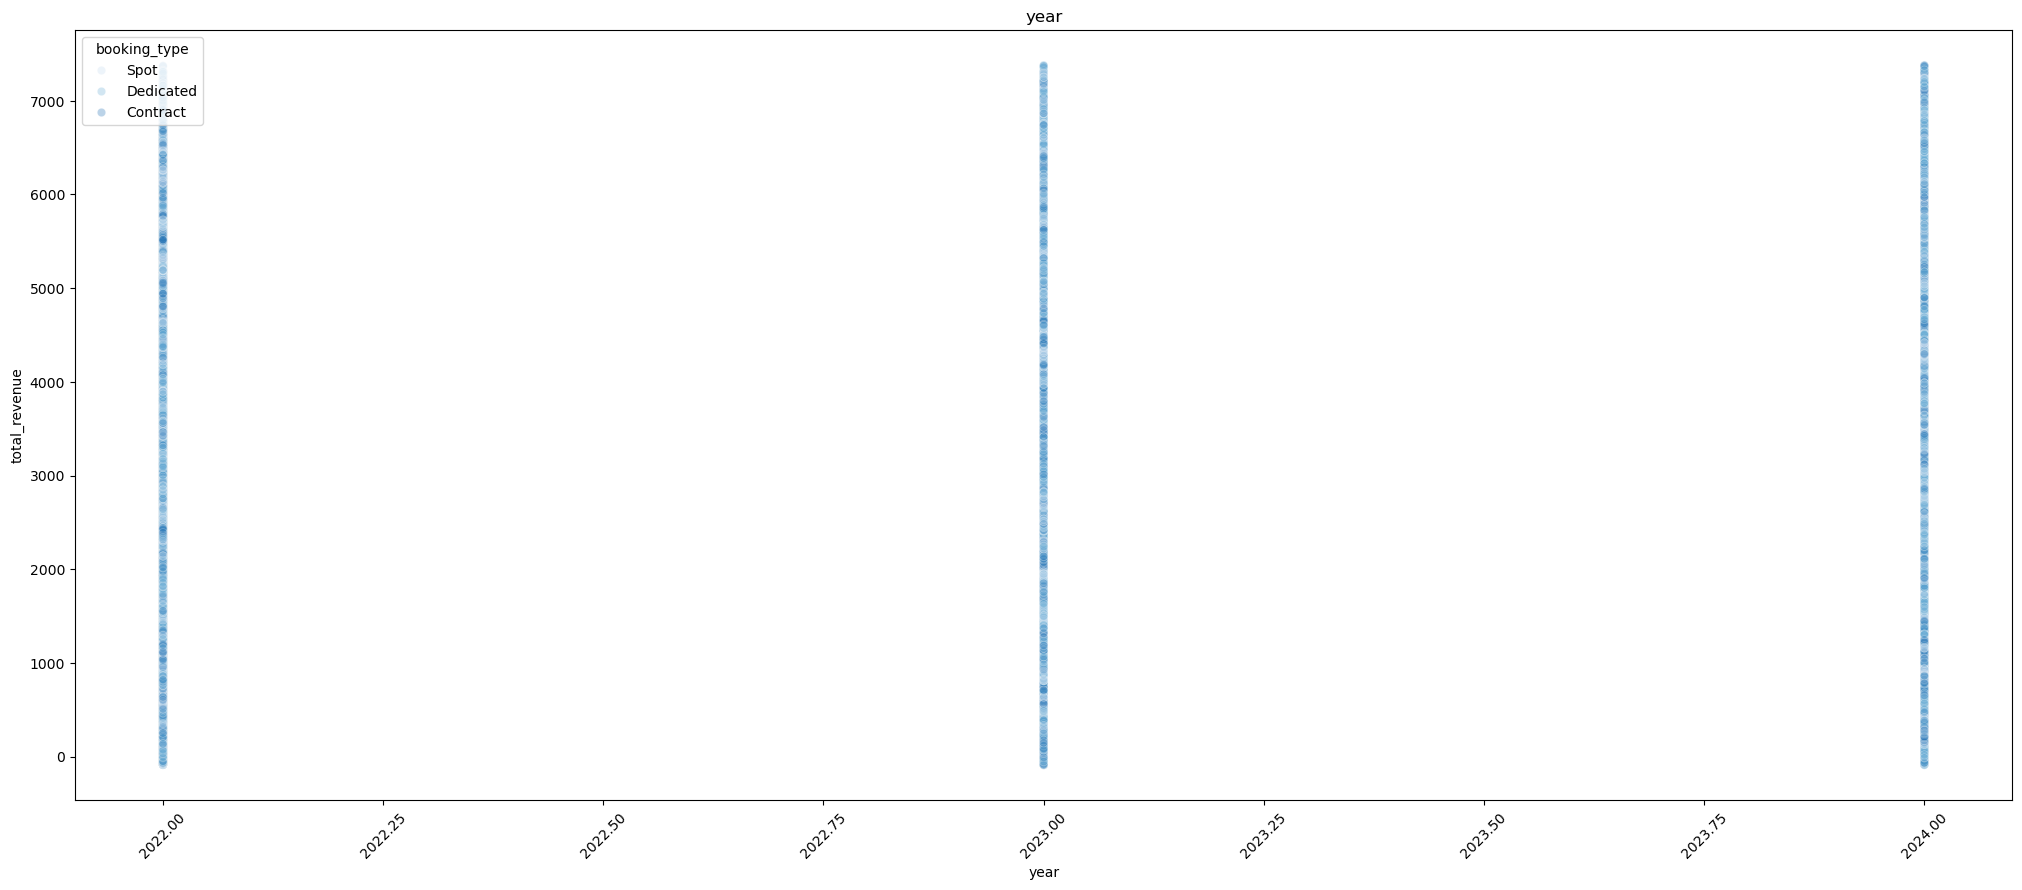

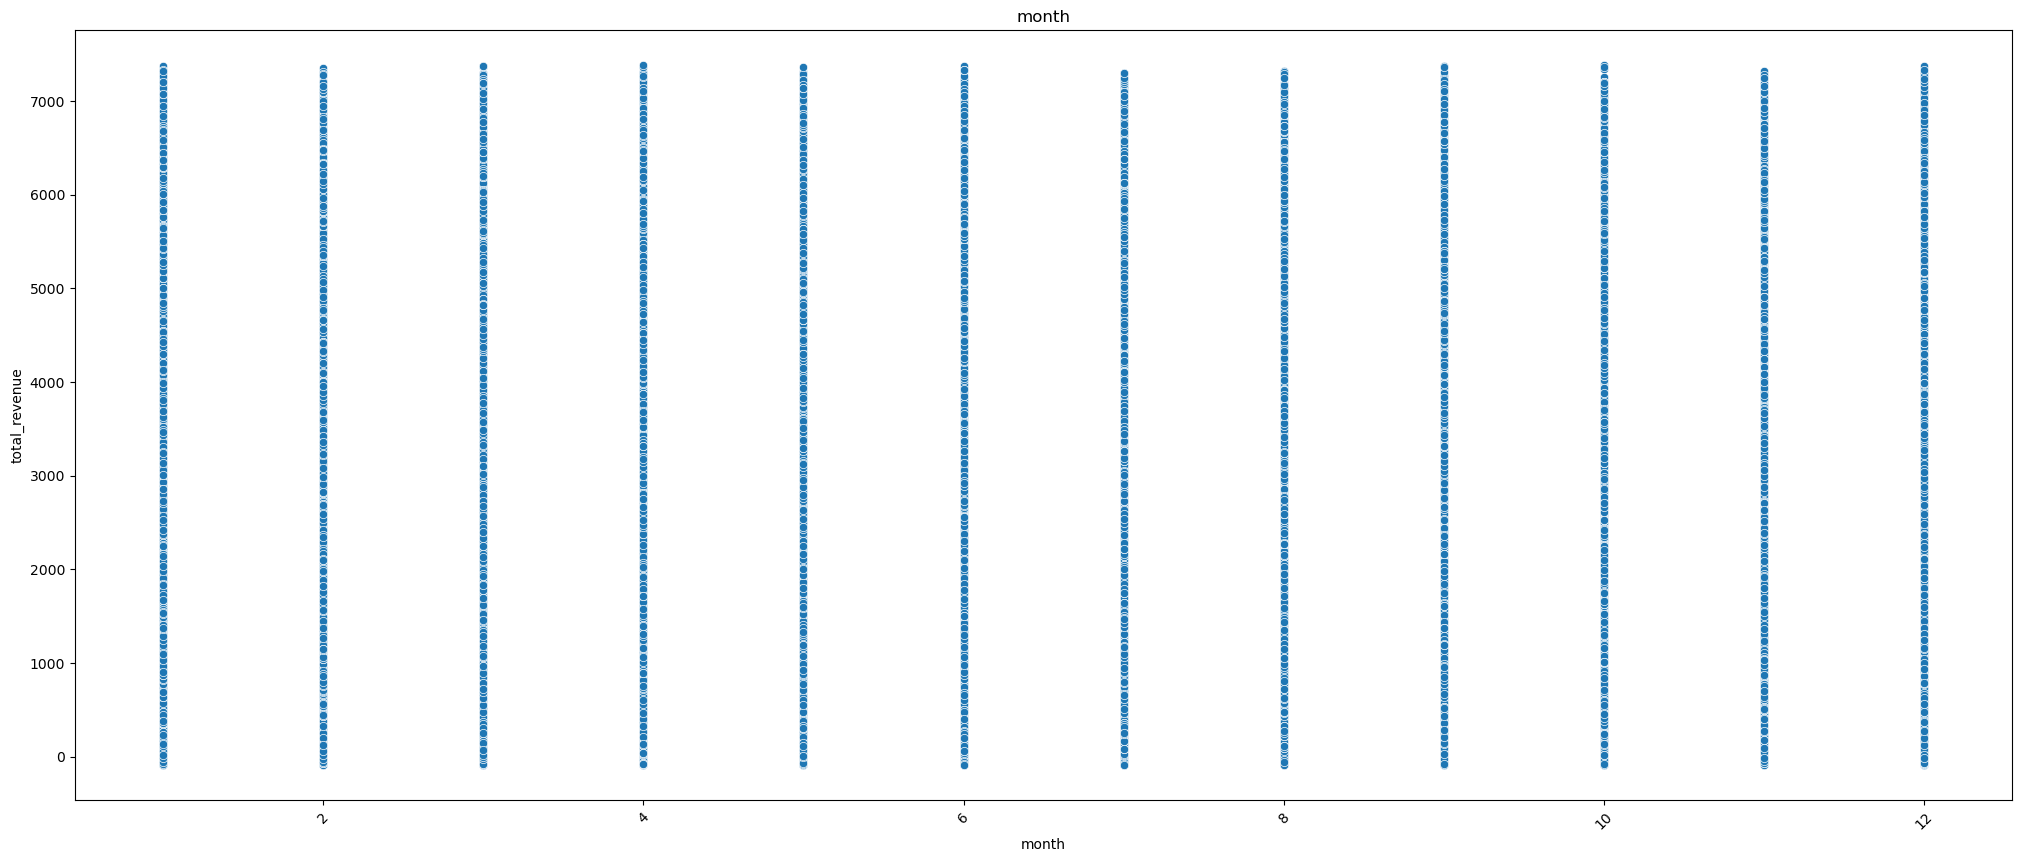

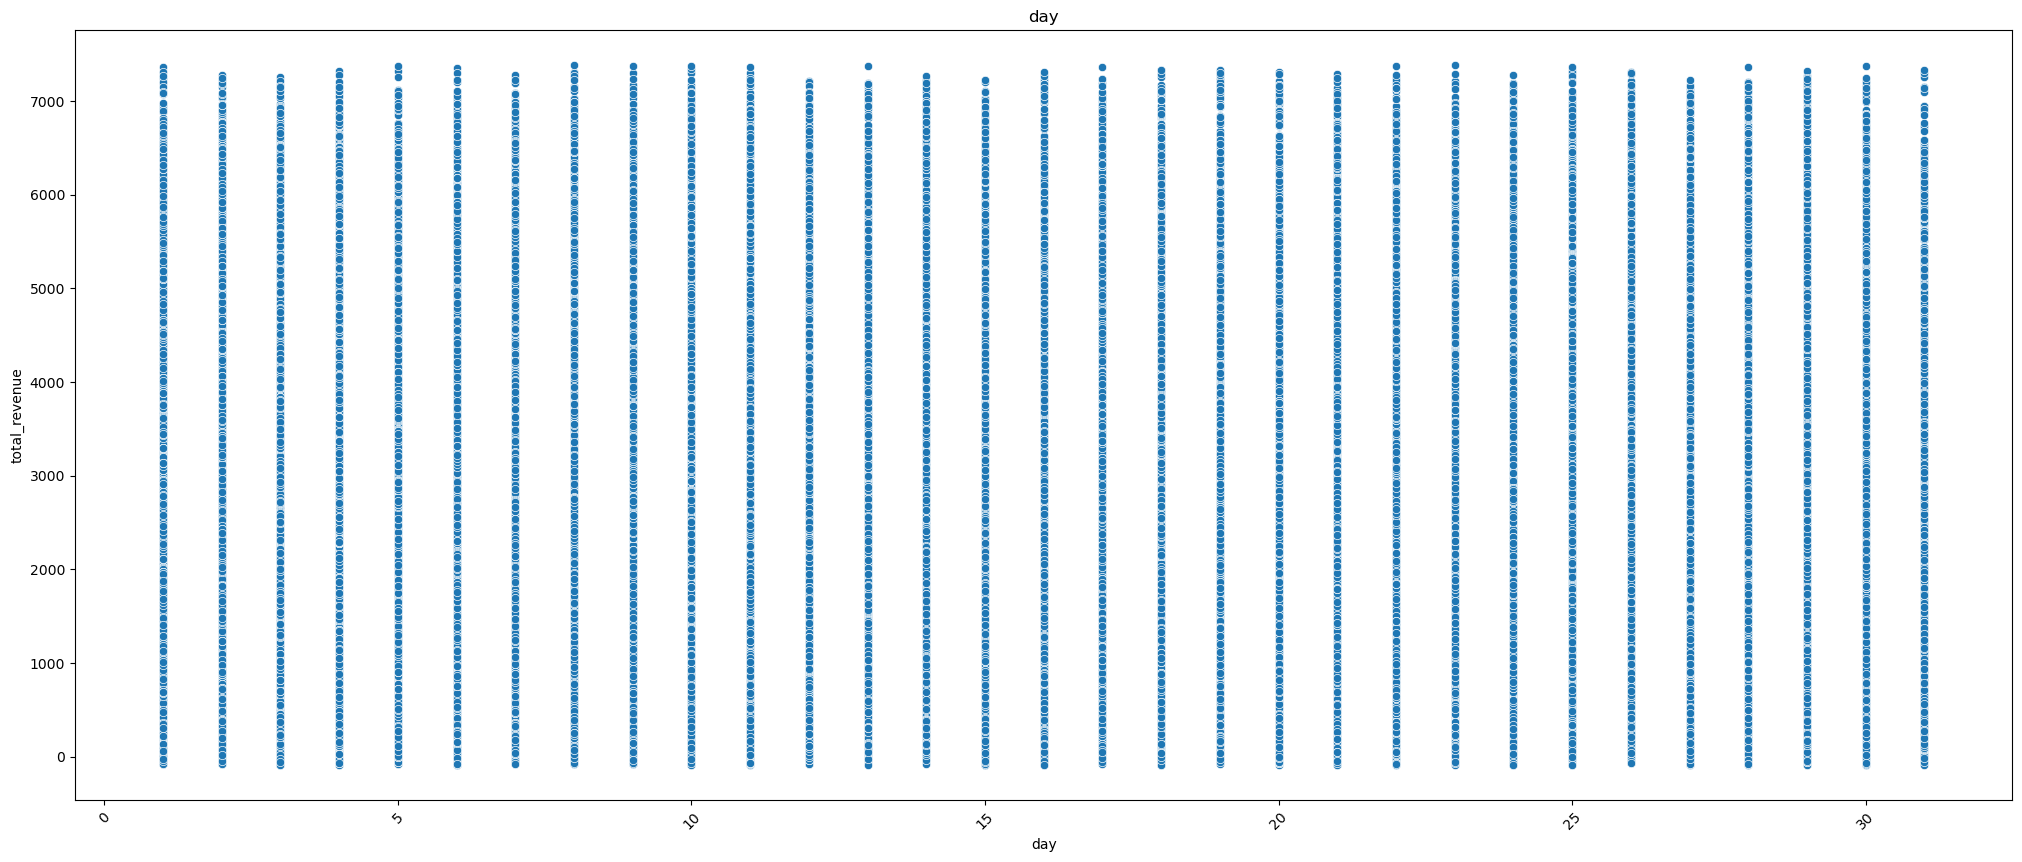

In [ ]:
def generar_grafico_dispersion(y, x, hue=None):
    plt.figure(figsize=(25,10))
    
    if hue == None:
        sns.scatterplot(x=df[x], y=df[y])
    else:
        sns.scatterplot(x=df[x], y=df[y], hue=df[hue], alpha=0.3, palette='Blues')
    
    plt.title(x)
    plt.xlabel(x)
    plt.xticks(rotation=45)
    plt.ylabel(y)
    plt.show()
    
generar_grafico_dispersion('total_revenue', 'year',)
generar_grafico_dispersion('total_revenue', 'month')
generar_grafico_dispersion('total_revenue', 'day')